In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
import tensorflow as tf

model_path = "/content/drive/MyDrive/Chatbot/Routing_Models/routing_model_epoch_09.h5"

model = tf.keras.models.load_model(model_path)
print("Model loaded")

Model loaded


In [81]:
class_names = ['crop', 'disease', 'ocr_dataset', 'pest', 'soil', 'weed']

In [82]:
from google.colab import files

uploaded = files.upload()

# get uploaded file name
img_path = list(uploaded.keys())[0]
print("Uploaded:", img_path)

Saving test32.jpeg to test32.jpeg
Uploaded: test32.jpeg


In [83]:
import numpy as np
from tensorflow.keras.preprocessing import image

IMG_SIZE = 224

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    label = class_names[np.argmax(pred)]
    confidence = float(np.max(pred))

    return label, confidence

In [84]:
label, conf = predict_image(img_path)

print("Prediction:", label)
print("Confidence:", conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: weed
Confidence: 0.9999978542327881


(np.float64(-0.5), np.float64(312.5), np.float64(311.5), np.float64(-0.5))

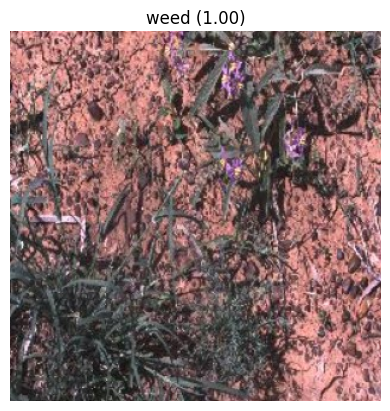

In [85]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img = image.load_img(img_path)
plt.imshow(img)
plt.title(f"{label} ({conf:.2f})")
plt.axis("off")